# DA 351 Lab 5: Advanced Image Classification  

- Names: Bach Nguyen, Ichhit Joshi, Suveer Singh, and Zach Riethof 
- Date:  4/16/2024

- Question Topic
    - In this analysis, our group will use the TensorFlow package in Python to classify folders containing images of different North American birds. We are basing our approach on the article 'Building a Bird Recognition App and Large Scale Dataset With Citizen Scientists: The Fine Print in Fine-Grained Dataset Collection'.

## Introduction

- This week's lab is based on an article titled 'Building a Bird Recognition App and Large Scale Dataset With Citizen Scientists: The Fine Print in Fine-Grained Dataset Collection,' authored by the SE(3) Computer Vision Group at Cornell University. The dataset they created, NABirds, contains 48,562 images of North American birds categorized into 555 categories. However, the main issue with this dataset is its size—it is quite large, with a size of 9.8 GB compressed on my disk and 9.99 GB after extraction. Our group for this lab has decided to work with the Caltech-UCSD Birds-200-2011 Dataset (CUB 200), which was the go-to dataset for bird recognition and classification before NABirds. CUB 200 is still fairly large at 1.2 GB compressed, but it is significantly smaller than 9.8 GB. 

- In this lab, we aim to classify images of different North American birds using the Caltech-UCSD Birds-200-2011 Dataset (CUB 200). Some questions we are trying to answer include: Can we accurately classify different species of North American birds based on their images? Are there specific features or characteristics of bird images that are particularly informative for classification?

- The stakeholders for our data analysis lab include us as students, serving as the team members responsible for carrying out tasks to achieve the project's overall goals. Another significant stakeholder is our professor, Mr. Lavin, as he oversees our project and provides assistance on tasks if needed. Additionally, Cornell University is a stakeholder, as the dataset for this project was researched and compiled by this institution. They might be interested in the outcomes of our work. In our project we are committed to upholding ethical standards throughout the process of are work. We recognize the importance of data privacy and are ensuring that the images used for classification are obtained and used in compliance with privacy regulations. To mitigate bias, we are carefully selecting a diverse and representative dataset for training and testing our models. We are also transparently documenting the architecture and parameters of our CNN models to ensure transparency. Additionally, we are monitoring our models' performance across different categories to detect and mitigate any bias.    

## Code & Results

In [53]:
%matplotlib inline
import tensorflow as tf
import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from keras.preprocessing import image
import cv2
from sklearn.metrics import confusion_matrix, precision_score, recall_score
import seaborn as sns
import os
import glob
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

### Training and Evaluating 10 Binary Classification Models

Found 120 files belonging to 2 classes.
Using 84 files for training.
Found 120 files belonging to 2 classes.
Using 36 files for validation.
Found 120 files belonging to 2 classes.
36/36 [==============================] - 0s 9ms/step

Model Accuracy of pairing a :
0.5555555555555556

Confusion Matrix of pairing a :
[[12  8]
 [ 8  8]]


True Negatives (TN) of pairing a : 12
False Positives (FP) of pairing a : 8
False Negatives (FN) of pairing a : 8
True Positives (TP) of pairing a : 8

Precision of pairing a :
[0.6 0.5]

Recall of pairing a :
[0.6 0.5]


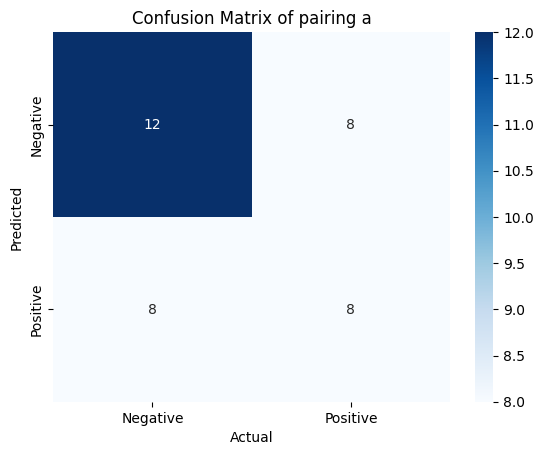

Found 120 files belonging to 2 classes.
Using 84 files for training.
Found 120 files belonging to 2 classes.
Using 36 files for validation.
Found 120 files belonging to 2 classes.
36/36 [==============================] - 0s 8ms/step

Model Accuracy of pairing b :
0.7222222222222222

Confusion Matrix of pairing b :
[[15  5]
 [ 5 11]]


True Negatives (TN) of pairing b : 15
False Positives (FP) of pairing b : 5
False Negatives (FN) of pairing b : 5
True Positives (TP) of pairing b : 11

Precision of pairing b :
[0.75   0.6875]

Recall of pairing b :
[0.75   0.6875]


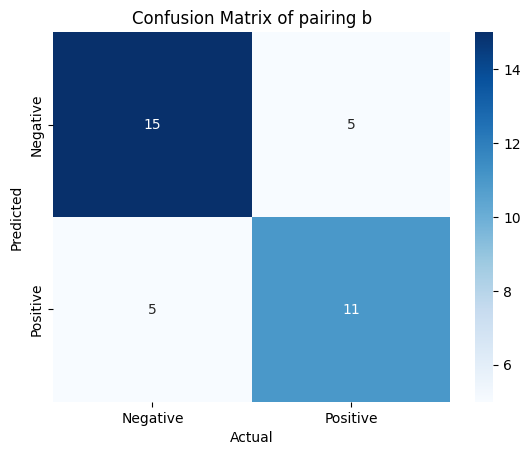

Found 120 files belonging to 2 classes.
Using 84 files for training.
Found 120 files belonging to 2 classes.
Using 36 files for validation.
Found 120 files belonging to 2 classes.
36/36 [==============================] - 0s 9ms/step

Model Accuracy of pairing c :
0.8888888888888888

Confusion Matrix of pairing c :
[[18  2]
 [ 2 14]]


True Negatives (TN) of pairing c : 18
False Positives (FP) of pairing c : 2
False Negatives (FN) of pairing c : 2
True Positives (TP) of pairing c : 14

Precision of pairing c :
[0.9   0.875]

Recall of pairing c :
[0.9   0.875]


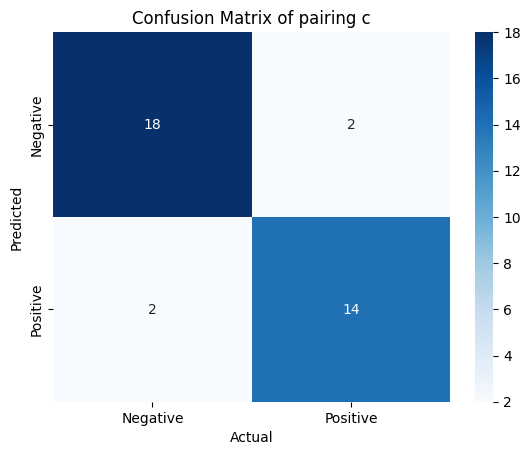

Found 120 files belonging to 2 classes.
Using 84 files for training.
Found 120 files belonging to 2 classes.
Using 36 files for validation.
Found 120 files belonging to 2 classes.
36/36 [==============================] - 0s 8ms/step

Model Accuracy of pairing d :
0.8333333333333334

Confusion Matrix of pairing d :
[[17  3]
 [ 3 13]]


True Negatives (TN) of pairing d : 17
False Positives (FP) of pairing d : 3
False Negatives (FN) of pairing d : 3
True Positives (TP) of pairing d : 13

Precision of pairing d :
[0.85   0.8125]

Recall of pairing d :
[0.85   0.8125]


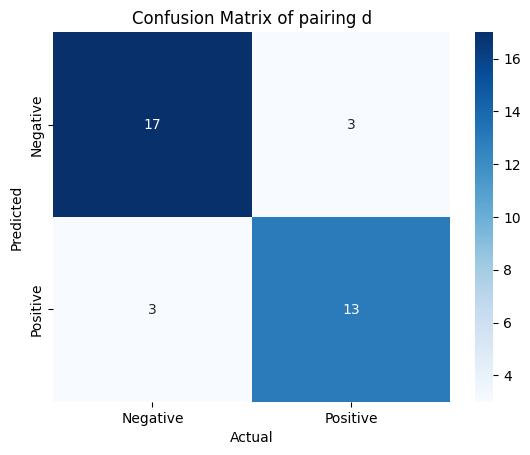

Found 110 files belonging to 2 classes.
Using 77 files for training.
Found 110 files belonging to 2 classes.
Using 33 files for validation.
Found 110 files belonging to 2 classes.
33/33 [==============================] - 0s 8ms/step

Model Accuracy of pairing e :
1.0

Confusion Matrix of pairing e :
[[19  0]
 [ 0 14]]


True Negatives (TN) of pairing e : 19
False Positives (FP) of pairing e : 0
False Negatives (FN) of pairing e : 0
True Positives (TP) of pairing e : 14

Precision of pairing e :
[1. 1.]

Recall of pairing e :
[1. 1.]


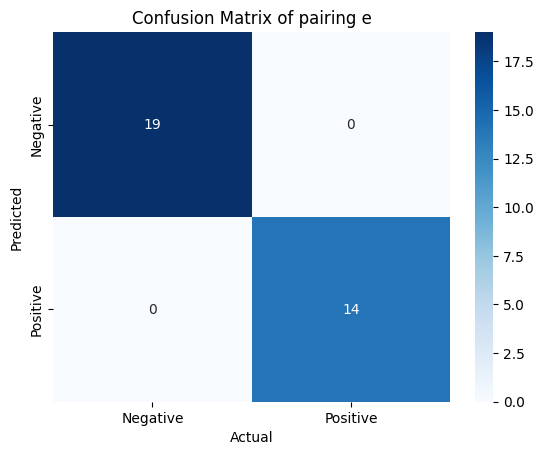

Found 118 files belonging to 2 classes.
Using 83 files for training.
Found 118 files belonging to 2 classes.
Using 35 files for validation.
Found 118 files belonging to 2 classes.
35/35 [==============================] - 0s 8ms/step

Model Accuracy of pairing f :
0.8285714285714286

Confusion Matrix of pairing f :
[[17  3]
 [ 3 12]]


True Negatives (TN) of pairing f : 17
False Positives (FP) of pairing f : 3
False Negatives (FN) of pairing f : 3
True Positives (TP) of pairing f : 12

Precision of pairing f :
[0.85 0.8 ]

Recall of pairing f :
[0.85 0.8 ]


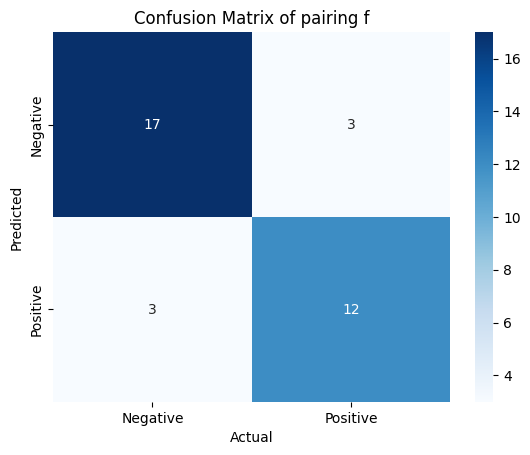

Found 120 files belonging to 2 classes.
Using 84 files for training.
Found 120 files belonging to 2 classes.
Using 36 files for validation.
Found 120 files belonging to 2 classes.
36/36 [==============================] - 0s 9ms/step

Model Accuracy of pairing g :
0.7777777777777778

Confusion Matrix of pairing g :
[[16  4]
 [ 4 12]]


True Negatives (TN) of pairing g : 16
False Positives (FP) of pairing g : 4
False Negatives (FN) of pairing g : 4
True Positives (TP) of pairing g : 12

Precision of pairing g :
[0.8  0.75]

Recall of pairing g :
[0.8  0.75]


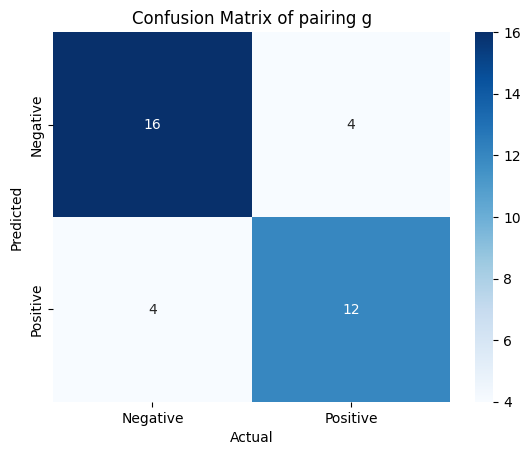

Found 118 files belonging to 2 classes.
Using 83 files for training.
Found 118 files belonging to 2 classes.
Using 35 files for validation.
Found 118 files belonging to 2 classes.
35/35 [==============================] - 0s 8ms/step

Model Accuracy of pairing h :
0.8285714285714286

Confusion Matrix of pairing h :
[[17  3]
 [ 3 12]]


True Negatives (TN) of pairing h : 17
False Positives (FP) of pairing h : 3
False Negatives (FN) of pairing h : 3
True Positives (TP) of pairing h : 12

Precision of pairing h :
[0.85 0.8 ]

Recall of pairing h :
[0.85 0.8 ]


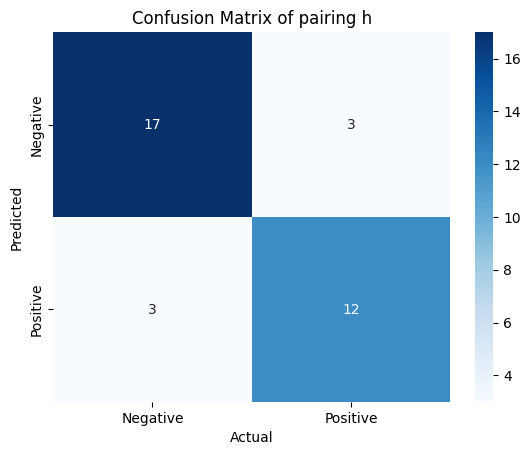

Found 120 files belonging to 2 classes.
Using 84 files for training.
Found 120 files belonging to 2 classes.
Using 36 files for validation.
Found 120 files belonging to 2 classes.
36/36 [==============================] - 0s 8ms/step

Model Accuracy of pairing i :
0.8888888888888888

Confusion Matrix of pairing i :
[[18  2]
 [ 2 14]]


True Negatives (TN) of pairing i : 18
False Positives (FP) of pairing i : 2
False Negatives (FN) of pairing i : 2
True Positives (TP) of pairing i : 14

Precision of pairing i :
[0.9   0.875]

Recall of pairing i :
[0.9   0.875]


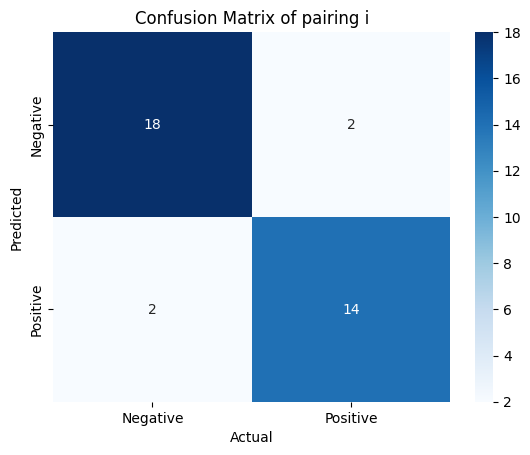

Found 110 files belonging to 2 classes.
Using 77 files for training.
Found 110 files belonging to 2 classes.
Using 33 files for validation.
Found 110 files belonging to 2 classes.
33/33 [==============================] - 0s 9ms/step

Model Accuracy of pairing j :
0.696969696969697

Confusion Matrix of pairing j :
[[17  5]
 [ 5  6]]


True Negatives (TN) of pairing j : 17
False Positives (FP) of pairing j : 5
False Negatives (FN) of pairing j : 5
True Positives (TP) of pairing j : 6

Precision of pairing j :
[0.77272727 0.54545455]

Recall of pairing j :
[0.77272727 0.54545455]


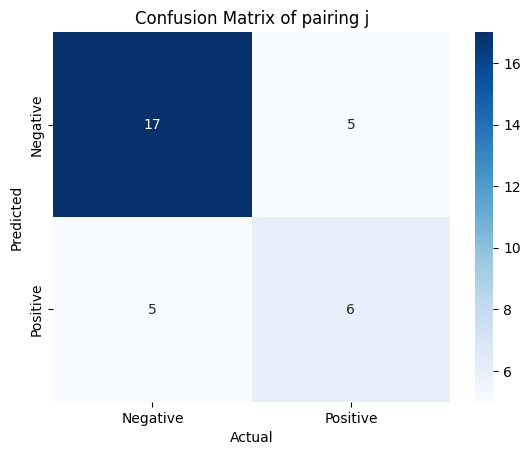

In [54]:
# Dictionary to store all 10 models
trained_models = {}

for pairing in sorted(os.listdir('bird_images')):
    
    model = tf.keras.models.Sequential([
    # Note the input shape is the desired size of the image 200x200 with 3 bytes color
    # The first convolution
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(200, 200, 3)),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Dropout(0.25),
    # The second convolution
    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Dropout(0.25),
    # The third convolution
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Dropout(0.25),
    # Flatten the results to feed into a DNN
    tf.keras.layers.Flatten(),
    # 512 neuron hidden layer
    tf.keras.layers.Dense(512, activation='relu'),
    # Only 1 output neuron. It will contain a value from 0-1 
    tf.keras.layers.Dense(1, activation='sigmoid')])

    RMSprop = tf.keras.dtensor.experimental.optimizers.RMSprop
    model.compile(loss='binary_crossentropy',optimizer=RMSprop(),metrics='accuracy')

    pairing_path = os.path.join('bird_images', pairing)

    # Check if the path is a directory
    if os.path.isdir(pairing_path):
        training_set = tf.keras.utils.image_dataset_from_directory(
            pairing_path,
            seed=123,
            image_size=(200, 200),
            subset='training',
            validation_split=0.3,
            batch_size=5)

        validation_set = tf.keras.utils.image_dataset_from_directory(
            pairing_path,
            shuffle=True,
            seed=17,
            image_size=(200, 200),
            validation_split=0.3,
            subset='validation',
            batch_size=5)

        holdout_set_all = tf.keras.utils.image_dataset_from_directory(
            pairing_path,
            shuffle=False,
            seed=17,
            image_size=(200, 200),
            batch_size=1) # batch size has to be one for this set

        # Extracting file paths from datasets for further processing
        train_file_paths = training_set.file_paths
        validation_file_paths = validation_set.file_paths
        holdout_file_paths = holdout_set_all.file_paths

        # Extracting images and labels from the holdout set for later use
        images = []
        labels = []
        for e, image_label in enumerate(holdout_set_all):
            f = holdout_file_paths[e]
            if f in validation_file_paths:
                images.append(image_label[0].numpy())
                labels.append(image_label[1].numpy())

        # Fitting the model to the training data and validating it on the validation set
        history = model.fit(training_set,
            epochs=9,
            verbose=0, # Disabling output
            validation_data = validation_set)

        model.evaluate(validation_set)

        # Predicting labels for images in the holdout set
        img_arrays = []
        for i in images:
            img_arrays.append(i)

        test_dataset = tf.data.Dataset.from_tensor_slices(img_arrays)
        preds = model.predict(test_dataset)

        # Counting occurrences of each label in the holdout set
        from collections import Counter
        c = Counter([i[0] for i in labels])

        df = pd.DataFrame()
        df['true_label'] = [i[0] for i in labels]
        df['predict_probability'] = [i[0] for i in preds]
        df = df.sort_values(by='predict_probability')
        inferred_labels = [0 for i in range(c[0])] + [1 for i in range(c[1])]
        df['predicted_label'] = inferred_labels 
        df['compare'] = df['true_label'] == df['predicted_label']

        # Print model accuracy
        print("\nModel Accuracy of pairing", pairing[8], ":")
        print(len(df.loc[df['compare'] == True])/len(df))

        # Store trained model in dictionary
        trained_models[pairing] = model

        # Calculating confusion matrix, precision, and recall
        true_labels = df['true_label'].to_numpy()
        predicted_labels = df['predicted_label'].to_numpy()

        conf_matrix = confusion_matrix(true_labels, predicted_labels)
        precision = precision_score(true_labels, predicted_labels, average=None)
        recall = recall_score(true_labels, predicted_labels, average=None)

        # Printing confusion matrix, precision, and recall
        print("\nConfusion Matrix of pairing", pairing[8], ":")
        print(conf_matrix)
        print("\n")
        TN, FP, FN, TP = conf_matrix.ravel()

        # Print TP, TN, FP, FN
        print("True Negatives (TN) of pairing", pairing[8], ":", TN)
        print("False Positives (FP) of pairing", pairing[8], ":", FP)
        print("False Negatives (FN) of pairing", pairing[8], ":", FN)
        print("True Positives (TP) of pairing", pairing[8], ":", TP)

        print("\nPrecision of pairing", pairing[8], ":")
        print(precision)
        print("\nRecall of pairing", pairing[8], ":")
        print(recall)

        # Plotting the confusion matrix as a heatmap
        xlabels = ["Negative", "Positive"]
        ylabels = ["Negative", "Positive"]

        plot_title = "Confusion Matrix of pairing " + pairing[8]
        sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=xlabels, yticklabels=ylabels)
        plt.xlabel('Actual')
        plt.ylabel('Predicted')
        plt.title(plot_title)
        plt.show()

In [55]:
trained_models

{'pairing_a_(h)': <keras.src.engine.sequential.Sequential at 0x2e1d4a910>,
 'pairing_b_(h)': <keras.src.engine.sequential.Sequential at 0x37a04a670>,
 'pairing_c_(m)': <keras.src.engine.sequential.Sequential at 0x37b93ec40>,
 'pairing_d_(e)': <keras.src.engine.sequential.Sequential at 0x29edf7df0>,
 'pairing_e_(e)': <keras.src.engine.sequential.Sequential at 0x3d86ad250>,
 'pairing_f_(m)': <keras.src.engine.sequential.Sequential at 0x29ed317f0>,
 'pairing_g_(e)': <keras.src.engine.sequential.Sequential at 0x40e7cce80>,
 'pairing_h_(e)': <keras.src.engine.sequential.Sequential at 0x4216e07f0>,
 'pairing_i_(m)': <keras.src.engine.sequential.Sequential at 0x42f8f6e50>,
 'pairing_j_(h)': <keras.src.engine.sequential.Sequential at 0x439e887f0>}

### Using Binary Models to Describe Novel Data

In [56]:
def predict_with_models(novel_species_path, trained_models):
    novel_dataset = tf.keras.utils.image_dataset_from_directory(
        novel_species_path,
        labels=None,
        shuffle=False,
        image_size=(200, 200),
        batch_size=1
    )

    # Get all file paths for the novel species images
    file_paths = sorted(glob.glob(f"{novel_species_path}/*"))

    # Predict with each model
    predictions = {}
    for model_name, model in trained_models.items():
        predictions[model_name] = []

        for image_batch in novel_dataset:
            pred = model.predict(image_batch)
            predictions[model_name].append(pred[0][0])
        
    # Create DataFrame
    df = pd.DataFrame.from_dict(predictions)
    df['Image'] = file_paths  # Add file paths as a column
    return df


# Run prediction function for your novel species images
novel_species_df1 = predict_with_models('novel_species1_images', trained_models)
novel_species_df2 = predict_with_models('novel_species2_images', trained_models)

# Combine dataframes and add labels for the species
novel_species_df1['species'] = 'novel_species_1'
novel_species_df2['species'] = 'novel_species_2'
novel_species_df = pd.concat([novel_species_df1, novel_species_df2], ignore_index=True)

Found 60 files belonging to 1 classes.
1/1 [==============================] - 0s 17ms/step
Found 60 files belonging to 1 classes.
1/1 [==============================] - 0s 18ms/step


In [57]:
novel_species_df

,pairing_a_(h),pairing_b_(h),pairing_c_(m),pairing_d_(e),pairing_e_(e),pairing_f_(m),pairing_g_(e),pairing_h_(e),pairing_i_(m),pairing_j_(h),Image,species
0,0.520630,0.296986,0.533910,0.504645,0.054786,0.482921,0.512045,0.479657,0.264801,0.501426,novel_species1_images/Black_Footed_Albatross_0...,novel_species_1
1,0.527492,0.442789,0.647656,0.365921,0.003867,0.198479,0.613377,0.824117,0.794501,0.494477,novel_species1_images/Black_Footed_Albatross_0...,novel_species_1
2,0.526765,0.492357,0.283856,0.508583,0.009633,0.494923,0.602481,0.008318,0.000008,0.265136,novel_species1_images/Black_Footed_Albatross_0...,novel_species_1
3,0.527293,0.446582,0.319969,0.316472,0.030037,0.550248,0.545525,0.583206,0.039177,0.634872,novel_species1_images/Black_Footed_Albatross_0...,novel_species_1
4,0.520630,0.948163,0.534588,0.494961,0.007351,0.539372,0.481283,0.199481,0.164349,0.335067,novel_species1_images/Black_Footed_Albatross_0...,novel_species_1
...,...,...,...,...,...,...,...,...,...,...,...,...
115,0.533627,0.721260,0.500613,0.530740,0.997814,0.999555,0.269929,0.713212,0.953093,0.341212,novel_species2_images/Scarlet_Tanager_0129_137...,novel_species_2
116,0.472631,0.765573,0.323513,0.332221,0.968573,1.000000,0.003670,0.000701,0.000790,0.209985,novel_species2_images/Scarlet_Tanager_0130_138...,novel_species_2
117,0.532942,0.586353,0.510811,0.496962,0.983824,0.998156,0.288838,0.057261,0.000364,0.492426,novel_species2_images/Scarlet_Tanager_0131_138...,novel_species_2
118,0.520439,0.543281,0.566285,0.458596,0.999652,1.000000,0.651563,0.754424,0.963174,0.549932,novel_species2_images/Scarlet_Tanager_0132_138...,novel_species_2


### Classify

Overall Accuracy: 0.9583333333333334
Confusion Matrix:
 [[13  0]
 [ 1 10]]
Precision: [0.92857143 1.        ]
Recall: [1.         0.90909091]


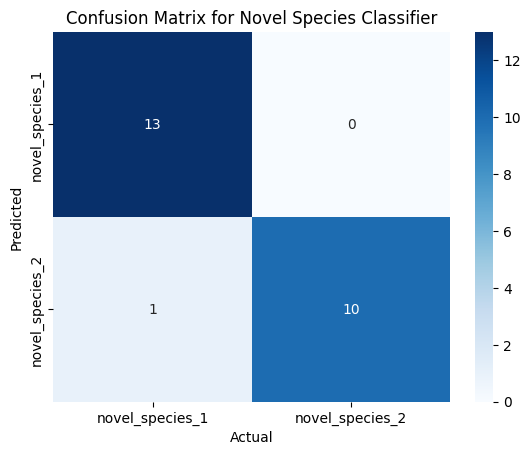

In [58]:
# Setting up data and labels
X = novel_species_df.drop(['Image', 'species'], axis=1)
y = novel_species_df['species']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# KNN classifier
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

# Evaluation
accuracy = knn.score(X_test, y_test)
conf_matrix = confusion_matrix(y_test, y_pred)
precision = precision_score(y_test, y_pred, average=None)
recall = recall_score(y_test, y_pred, average=None)

print("Overall Accuracy:", accuracy)
print("Confusion Matrix:\n", conf_matrix)
print("Precision:", precision)
print("Recall:", recall)

# Plotting the confusion matrix
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=knn.classes_, yticklabels=knn.classes_)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Confusion Matrix for Novel Species Classifier')
plt.show()

## Interpretation

Follow the guidelines in the `README` file

## Conclusion

Follow the guidelines in the `README` file